# Visualização da inferência — bundle SIMPred

Carrega um bundle de deploy (`deploy/Transpetro/<EQUIP>/modelos/model_*/`), roda a
inferência sobre os dados brutos do equipamento e plota o **erro de reconstrução vs.
thresholds** (atenção/alarme) ao longo do tempo, com os alarmes (já com debounce).

Troque `EQUIP` abaixo para ver outro equipamento. `DATA_FALHA` marca a falha conhecida,
`NORMAL_END` define o fim da janela normal (margem antes da falha) e `PRE_FALHA_DIAS`
quantos dias antes da falha mostrar no zoom.

In [6]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DEPLOY_ROOT = Path.cwd() if (Path.cwd() / "simpred_inference.py").exists() else Path.cwd() / "deploy"
sys.path.insert(0, str(DEPLOY_ROOT))
sys.path.insert(0, str(DEPLOY_ROOT.parent / "src"))
from simpred_inference import load_bundle, predict

# ── parâmetros ──
EQUIP = "B-8802B"
DATA_FALHA = "2022-07-06"   # data da falha conhecida (ou None)
NORMAL_END = "2022-06-30"   # fim da janela normal (margem antes da falha; None = usa DATA_FALHA)
PRE_FALHA_DIAS = 10         # dias antes da falha mostrados no zoom de pré-falha

EQ_DIR = DEPLOY_ROOT / "Transpetro" / EQUIP
BUNDLE_DIR = next((EQ_DIR / "modelos").glob("model_*"))
DATA_FILE = next((EQ_DIR / "dados").rglob("*_raw.csv"))
print("bundle:", BUNDLE_DIR.name)
print("dados :", DATA_FILE.name)

bundle: model_2022-05-15_2022-07-21_VAE
dados : data_2022-05-15_2022-07-21_raw.csv


In [7]:
bundle = load_bundle(BUNDLE_DIR)
result = predict(bundle, DATA_FILE)

n = len(result)
print(f"{EQUIP}: {n} instantes pontuados | model_type={bundle.model_type} | debounce={bundle.debounce_consecutive}")
print(f"threshold alarme={bundle.threshold:.4f} | atenção={bundle.threshold_attention}")
print("\nseveridade:")
print(result["severity"].value_counts().to_string())
result.head()

B-8802B: 10792 instantes pontuados | model_type=vae | debounce=6
threshold alarme=0.3900 | atenção=0.2102846503257751

severidade:
severity
normal     7907
atencao    2149
alarme      736


,reconstruction_error,is_anomaly,severity
Unnamed: 0,,,
2022-05-15 18:25:00,0.025280,False,normal
2022-05-15 18:30:00,0.275094,False,atencao
2022-05-15 18:35:00,0.118443,False,normal
2022-05-15 18:40:00,0.028583,False,normal
2022-05-15 18:45:00,0.078666,False,normal


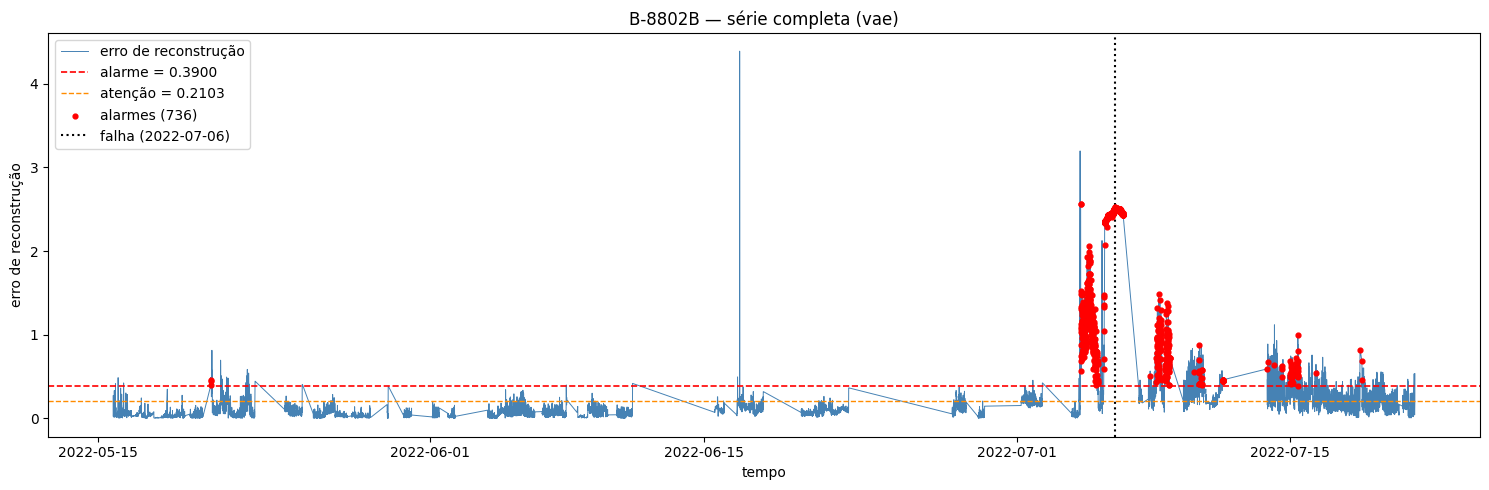

In [8]:
# Função reutilizável: plota o erro + thresholds + alarmes numa JANELA de tempo
def plot_window(df, bundle, ini=None, fim=None, titulo="", falha=None):
    win = df
    if ini is not None:
        win = win[win.index >= pd.to_datetime(ini)]
    if fim is not None:
        win = win[win.index <= pd.to_datetime(fim)]
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(win.index, win["reconstruction_error"], lw=0.7, color="steelblue",
            label="erro de reconstrução")
    ax.axhline(bundle.threshold, color="red", ls="--", lw=1.2, label=f"alarme = {bundle.threshold:.4f}")
    if bundle.threshold_attention is not None:
        ax.axhline(bundle.threshold_attention, color="darkorange", ls="--", lw=1.0,
                   label=f"atenção = {bundle.threshold_attention:.4f}")
    al = win[win["is_anomaly"]]
    ax.scatter(al.index, al["reconstruction_error"], s=12, color="red", zorder=3,
               label=f"alarmes ({len(al)})")
    if falha is not None:
        fd = pd.to_datetime(falha)
        if (ini is None or fd >= pd.to_datetime(ini)) and (fim is None or fd <= pd.to_datetime(fim)):
            ax.axvline(fd, color="black", ls=":", lw=1.5, label=f"falha ({falha})")
    ax.set_title(titulo); ax.set_xlabel("tempo"); ax.set_ylabel("erro de reconstrução")
    ax.legend(loc="upper left"); fig.tight_layout(); plt.show()
    return win

# Visão geral (série inteira)
plot_window(result, bundle, titulo=f"{EQUIP} — série completa ({bundle.model_type})", falha=DATA_FALHA);

## Zoom — pré-falha (lead time)

Janela dos `PRE_FALHA_DIAS` dias que antecedem a falha. Mostra quando o erro começa a subir e
qual a antecedência do primeiro alarme em relação à falha.

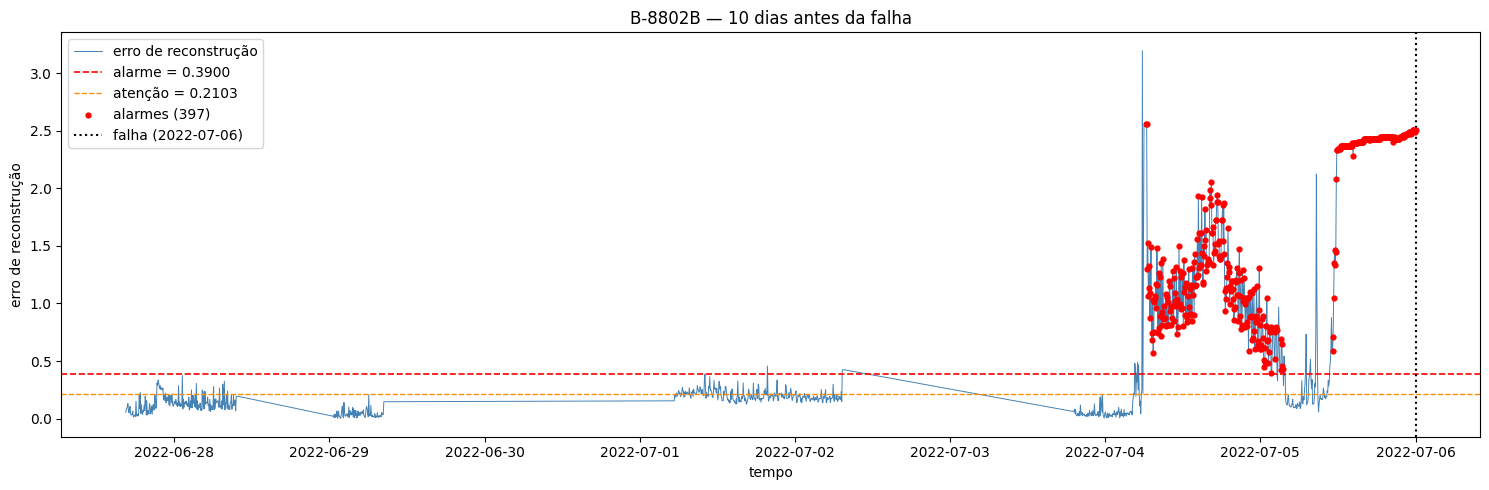

1º alarme: 2022-07-04 06:20:00  (lead time = 1 days 17:40:00)
alarmes na janela: 397 de 1261 pontos


In [9]:
if DATA_FALHA:
    fd = pd.to_datetime(DATA_FALHA)
    ini = fd - pd.Timedelta(days=PRE_FALHA_DIAS)
    pre = plot_window(result, bundle, ini=ini, fim=fd,
                      titulo=f"{EQUIP} — {PRE_FALHA_DIAS} dias antes da falha", falha=DATA_FALHA)
    al = pre[pre["is_anomaly"]]
    if len(al):
        lead = fd - al.index.min()
        print(f"1º alarme: {al.index.min()}  (lead time = {lead})")
        print(f"alarmes na janela: {len(al)} de {len(pre)} pontos")
    else:
        print("nenhum alarme nesta janela.")
else:
    print("defina DATA_FALHA para o zoom de pré-falha.")

## Zoom — pós-falha

Janela da falha em diante (até o fim dos dados). Útil para ver o comportamento do erro após o
evento (degradação contínua, parada, retorno ao normal pós-reparo).

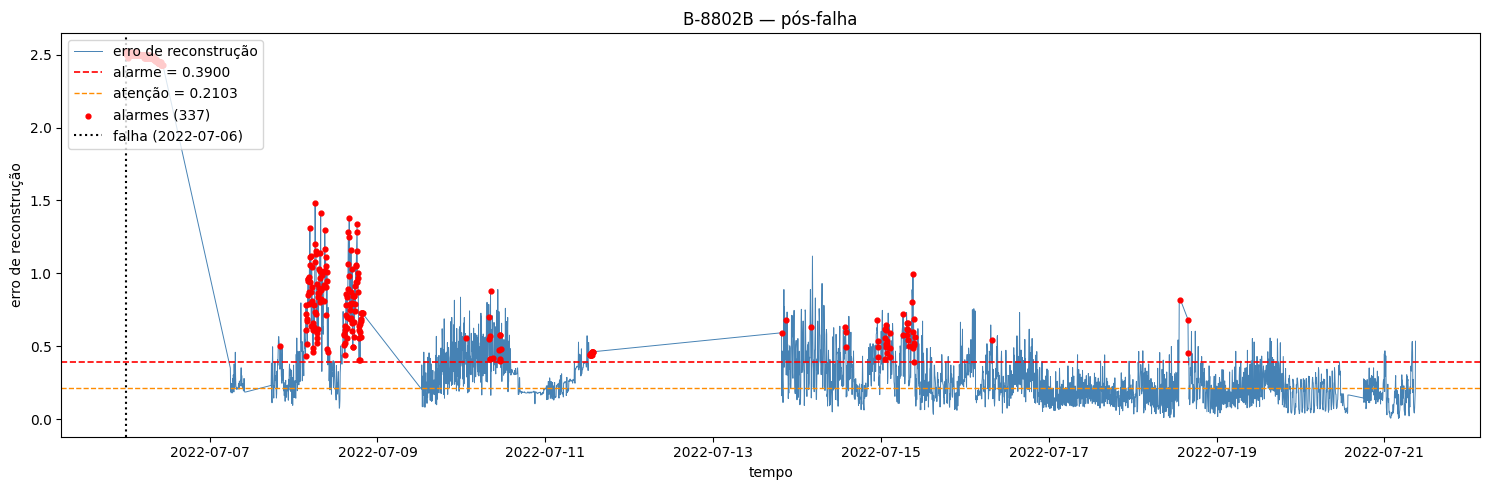

janela pós-falha: 2022-07-06 00:00:00 -> 2022-07-21 08:55:00 (3192 pts)
alarmes pós-falha: 337 (10.6%)


In [10]:
if DATA_FALHA:
    fd = pd.to_datetime(DATA_FALHA)
    pos = plot_window(result, bundle, ini=fd, titulo=f"{EQUIP} — pós-falha", falha=DATA_FALHA)
    print(f"janela pós-falha: {pos.index.min()} -> {pos.index.max()} ({len(pos)} pts)")
    print(f"alarmes pós-falha: {int(pos['is_anomaly'].sum())} ({100*pos['is_anomaly'].mean():.1f}%)")
else:
    print("defina DATA_FALHA para o zoom de pós-falha.")

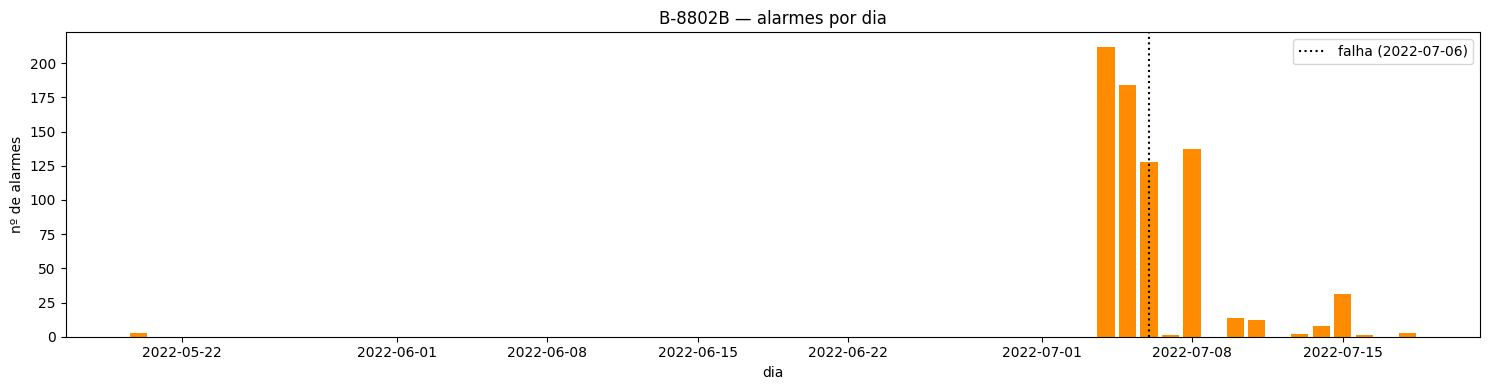

In [11]:
# Alarmes por dia — ajuda a ver concentração perto da falha (lead time)
por_dia = result["is_anomaly"].resample("1D").sum()
por_dia = por_dia[por_dia > 0]
fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(por_dia.index, por_dia.values, color="darkorange", width=0.8)
if DATA_FALHA:
    ax.axvline(pd.to_datetime(DATA_FALHA), color="black", ls=":", lw=1.5, label=f"falha ({DATA_FALHA})")
    ax.legend()
ax.set_title(f"{EQUIP} — alarmes por dia"); ax.set_xlabel("dia"); ax.set_ylabel("nº de alarmes")
fig.tight_layout(); plt.show()

## Concept drift — o que monitorar

O threshold é **calibrado numa janela normal** (quantil dos erros sob a meta de FP). Se o
regime normal do equipamento muda (reparo, troca de mancal, nova condição operacional), o erro
de reconstrução sobe de forma sustentada **mesmo sem falha** → falsos positivos. A célula abaixo
mede o FP **só na janela normal** (antes de `NORMAL_END`, sem a rampa de pré-falha): se subir
muito acima da meta, é sinal de drift e o modelo precisa ser **re-baselinado** (retreino).

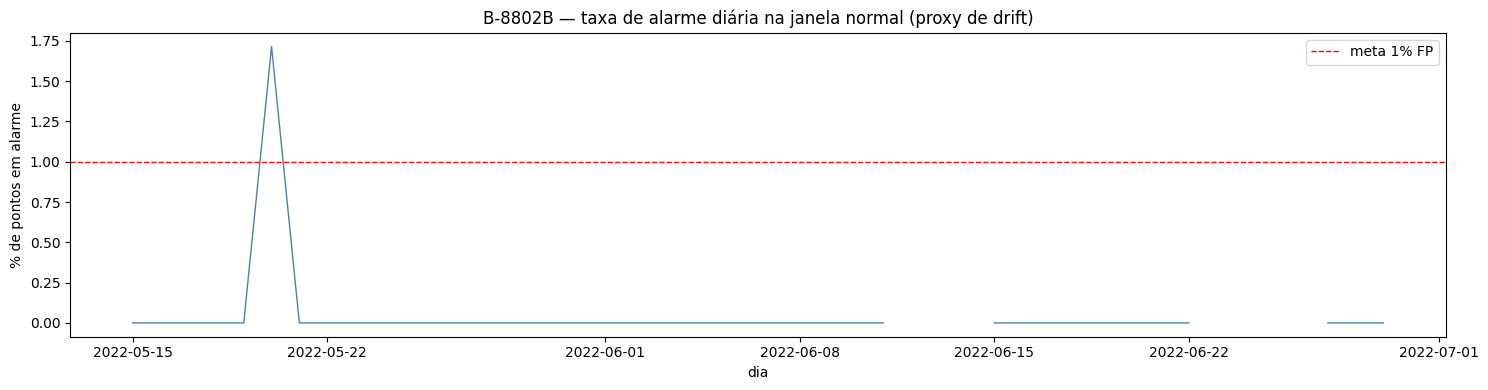

Janela normal: 2022-05-15 18:25:00 -> 2022-06-29 08:45:00 (6649 pts)
FP global na janela normal: 0.05%  (meta ~1%)


In [12]:
# FP na janela NORMAL (antes de NORMAL_END — exclui a rampa de pré-falha)
corte = pd.to_datetime(NORMAL_END or DATA_FALHA)
normal = result[result.index < corte] if corte is not None else result
fp_global = 100 * normal["is_anomaly"].mean()
fp_diario = normal["is_anomaly"].resample("1D").mean() * 100
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(fp_diario.index, fp_diario.values, color="steelblue", lw=1)
ax.axhline(1.0, color="red", ls="--", lw=1, label="meta 1% FP")
ax.set_title(f"{EQUIP} — taxa de alarme diária na janela normal (proxy de drift)")
ax.set_xlabel("dia"); ax.set_ylabel("% de pontos em alarme")
ax.legend(); fig.tight_layout(); plt.show()
print(f"Janela normal: {normal.index.min()} -> {normal.index.max()} ({len(normal)} pts)")
print(f"FP global na janela normal: {fp_global:.2f}%  (meta ~1%)")